In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import os
import kagglehub
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline


import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download dataset
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
print("Path to dataset files:", path)
print(os.listdir(path))

# Load dataset
df = pd.read_csv(f"{path}/ai4i2020.csv")
df.head()

100%|██████████| 136k/136k [00:00<00:00, 35.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/versions/2
['ai4i2020.csv']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()

Shape: (10000, 14)
Columns: Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                  

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
# Print missing values and duplicate rows
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Number of duplicate rows:
0


In [7]:
df = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [8]:
# Add Temp difference and Mechanical load features
df['Temp difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Mechanical load'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp difference,Mechanical load
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0


In [9]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp difference,Mechanical load,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,False,True
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,True,False
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,True,False
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,True,False
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,True,False


In [10]:
# Show class counts and percentages for the target variable
print("Machine failure distribution:")
print(df['Machine failure'].value_counts())

print("\nMachine failure proportion:")
print(df['Machine failure'].value_counts(normalize=True))

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure proportion:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                 1.000000                 0.876107   
Process temperature [K]             0.876107                 1.000000   
Rotational speed [rpm]              0.022670                 0.019277   
Torque [Nm]                        -0.013778                -0.014061   
Tool wear [min]                     0.013853                 0.013488   
Machine failure                     0.082556                 0.035946   
Temp difference                    -0.699583                -0.268413   
Mechanical load                    -0.011474                -0.010952   
Type_L                              0.006676                 0.005564   
Type_M                              0.007958                 0.005831   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
Air temperature [K]                    0.022670    -0.013778         0.013853   
Process temperature [K]           

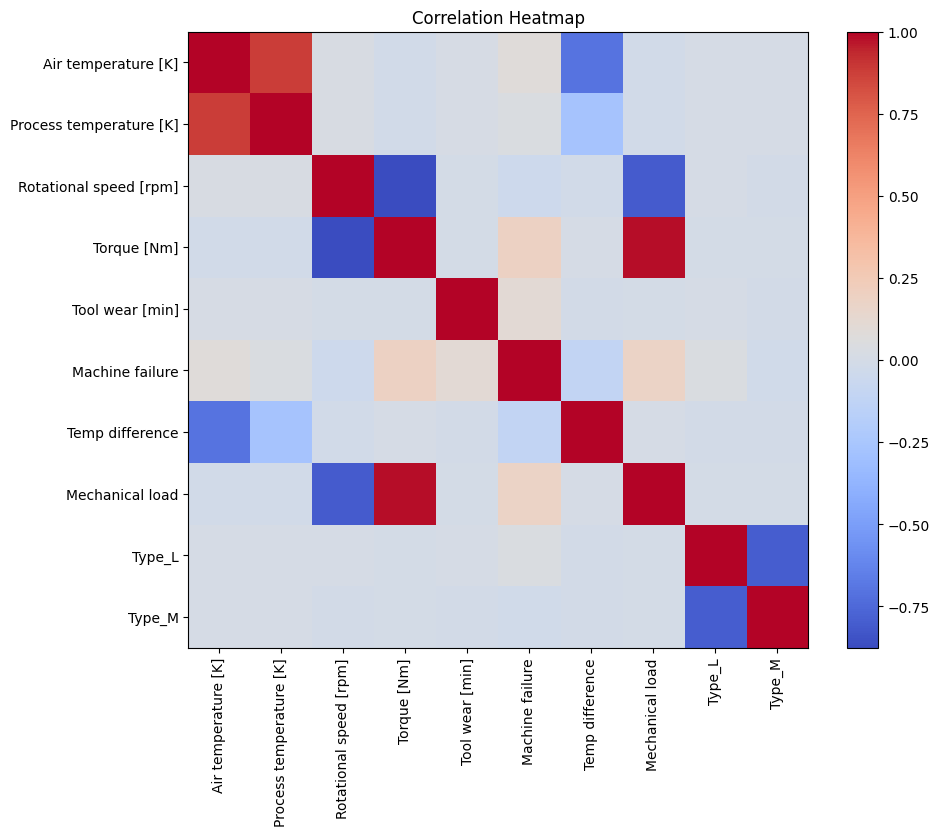

In [11]:
# Calculate the correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Correlation Heatmap')
plt.show()

In [12]:
# Separate the dataset into features (X) and the target variable (y)
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print("X head:")
print(X.head())

print("\ny head:")
print(y.head())

X head:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Temp difference  Mechanical load  Type_L  \
0         42.8                0             10.5          66382.8   False   
1         46.3                3             10.5          65190.4    True   
2         49.4                5             10.4          74001.2    True   
3         39.5                7             10.4          56603.5    True   
4         40.0                9             10.5          56320.0    True   

   Type_M  
0    True  
1   False  
2   False  
3   False  
4   False  

y hea

In [13]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64
y_test distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


Fitting 5 folds for each of 12 candidates, totalling 60 fits
🔹 RF Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
🔹 RF Best CV Score: 0.7133837199385981
Fitting 5 folds for each of 8 candidates, totalling 40 fits
🔹 GB Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
🔹 GB Best CV Score: 0.7183684839724153
Fitting 5 folds for each of 4 candidates, totalling 20 fits
🔹 LR Best Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
🔹 LR Best CV Score: 0.2809134806328652

📊 Random Forest
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.82      0.68        68

    accuracy                           0.97      2000
   macro avg       0.79      0.90      0.83      2000
weighted avg       0.98      0.97      0.98      2000

F1-Score: 0.6787878787878788

📊 Gradient Boosting
              precis

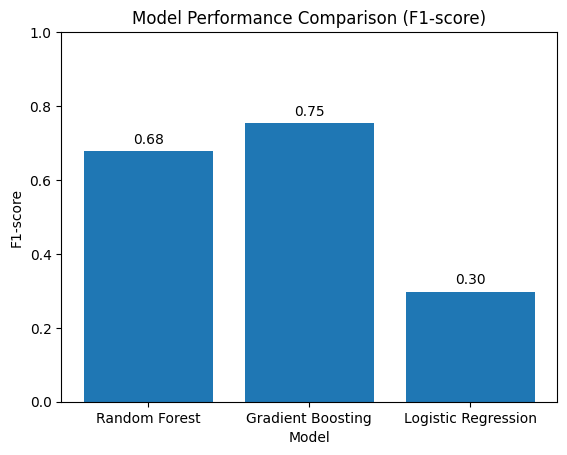

In [14]:
# ===============================
# 🔁 Cross-validation strategy
# ===============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===============================
# 🌲 Random Forest Pipeline + Grid
# ===============================
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("🔹 RF Best Params:", rf_grid.best_params_)
print("🔹 RF Best CV Score:", rf_grid.best_score_)


# ===============================
# 🌿 Gradient Boosting Pipeline + Grid
# ===============================
gb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("🔹 GB Best Params:", gb_grid.best_params_)
print("🔹 GB Best CV Score:", gb_grid.best_score_)


# ===============================
# 📉 Logistic Regression Pipeline + Grid
# ===============================
lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("🔹 LR Best Params:", lr_grid.best_params_)
print("🔹 LR Best CV Score:", lr_grid.best_score_)


# ===============================
# 🧪 Final Evaluation on Test Set
# ===============================
models = {
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_
}

f1_scores = {}

for name, model in models.items():
    print(f"\n📊 {name}")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    # Convert probabilities to binary predictions for F1-Score calculation
    y_pred_f1 = (y_proba > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred_f1)
    f1_scores[name] = f1
    print("F1-Score:", f1)


# Create bar chart for F1-score comparison
plt.figure()
plt.bar(f1_scores.keys(), f1_scores.values())

# Labels and title
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("Model Performance Comparison (F1-score)")
plt.ylim(0, 1)

# Show values on top of bars
for i, v in enumerate(f1_scores.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

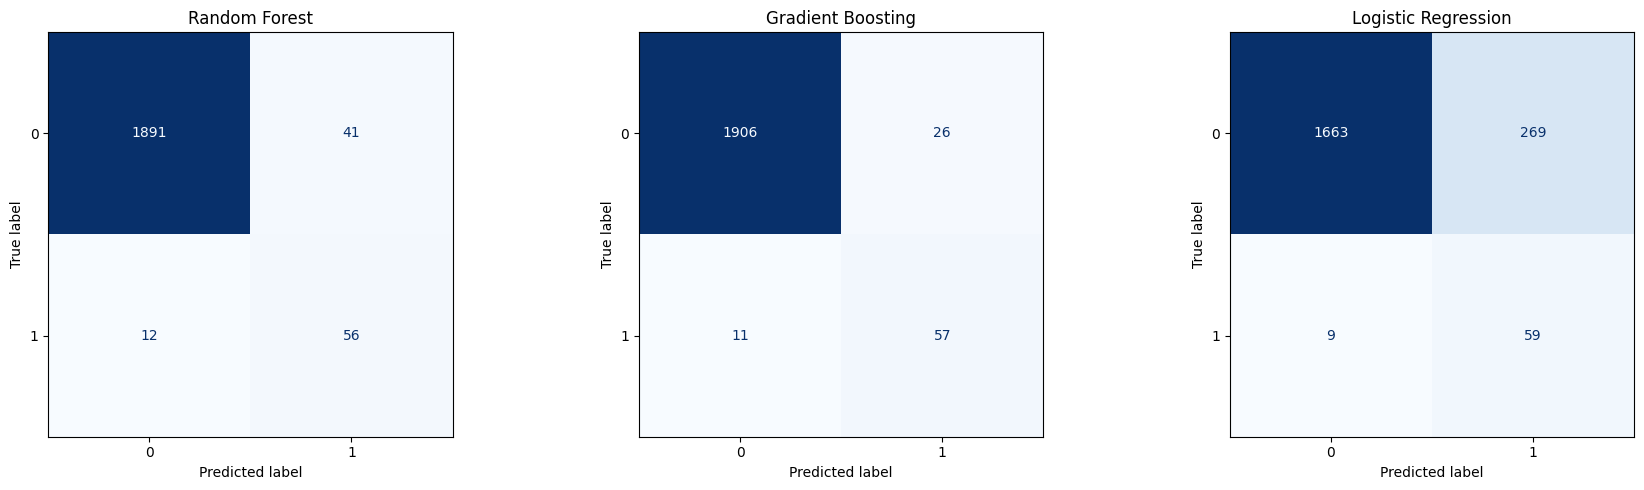

In [15]:
# ===============================
# 📊 Confusion Matrices (Models Chosen based on F1-Score)
# ===============================
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        cmap='Blues',
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

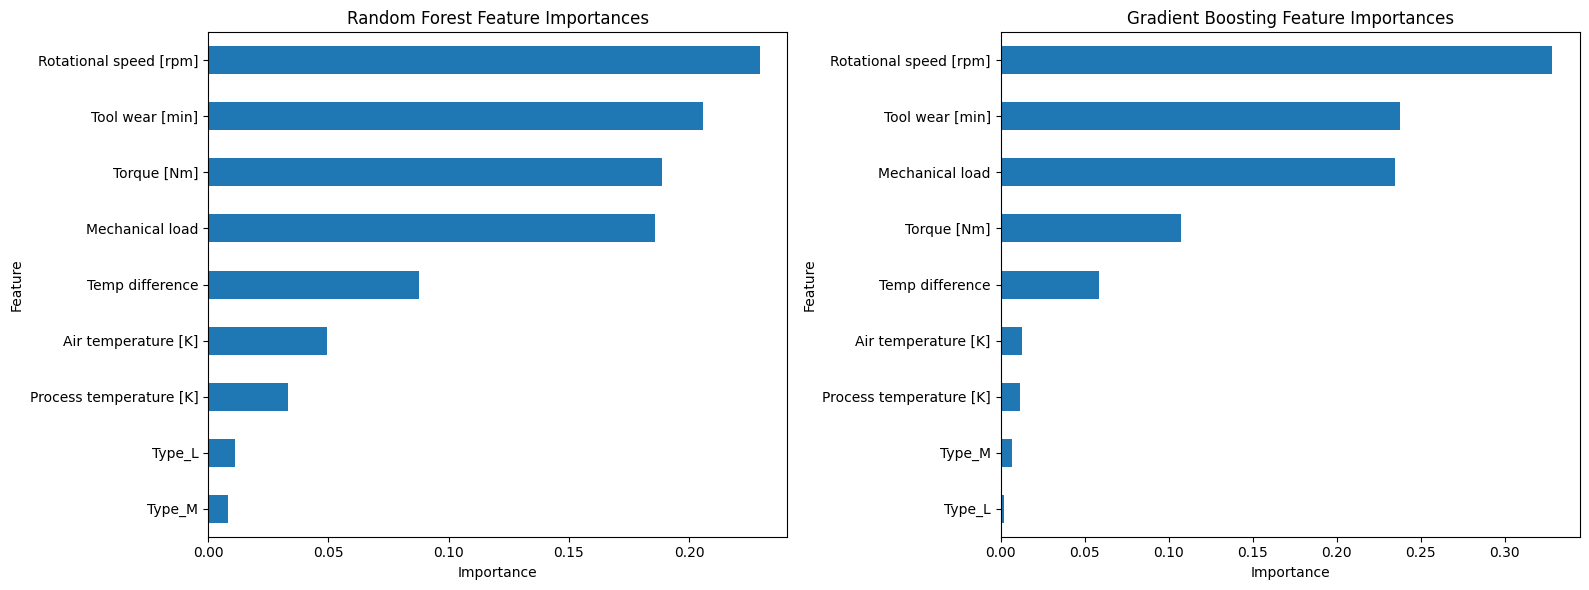

In [16]:
# ===============================
# 🌟 Generate Feature Importances
# ===============================

feature_names = X_train.columns.tolist()

tree_models = {
    "Random Forest": rf_grid.best_estimator_.named_steps["model"],
    "Gradient Boosting": gb_grid.best_estimator_.named_steps["model"]
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True)

    importances.plot(kind="barh", ax=ax)
    ax.set_title(f"{name} Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()